# 第1周 Day1：Python & PyTorch 基础

> **学习目标**：掌握 Python 基础语法、PyTorch 张量操作与训练循环
>
> **参考资源**：
> - 课程: [《动手学深度学习》](https://zh.d2l.ai/)
> - 数学: [3Blue1Brown - 线性代数的精髓](https://www.youtube.com/watch?v=fNk_zzaMoSs&list=PLZHQObOWTQDPD3MizzM2xVFitgF8hE_ab)
> - 补充: [台湾大学李宏毅深度学习](https://www.bilibili.com/video/BV1J94y1f7u5/)

---

## 📋 环境准备（首次运行请先执行下方单元格）

In [1]:
# 环境检查与依赖安装（只需运行一次）
import sys
print(f"Python 版本: {sys.version}")
print(f"Python 路径: {sys.executable}")

required = {'numpy', 'torch', 'matplotlib', 'ipykernel'}
installed = set()
missing = set()

for pkg in required:
    try:
        __import__(pkg)
        installed.add(pkg)
    except ImportError:
        missing.add(pkg)

print(f"\n已安装: {installed}")
if missing:
    print(f"缺少: {missing}")
    print("正在安装缺少的包...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install"] + list(missing))
    print("安装完成！请重启内核后继续。")
else:
    print("所有依赖已就绪！")
    import numpy as np
    import torch
    import matplotlib
    print(f"  numpy: {np.__version__}")
    print(f"  torch: {torch.__version__}")
    print(f"  matplotlib: {matplotlib.__version__}")
    print(f"  CUDA 可用: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"  GPU: {torch.cuda.get_device_name(0)}")

Python 版本: 3.11.15 | packaged by Anaconda, Inc. | (main, Jun 11 2026, 15:12:53) [MSC v.1942 64 bit (AMD64)]
Python 路径: c:\Users\WenhaoZou\.conda\envs\dl\python.exe

已安装: {'ipykernel', 'torch', 'numpy', 'matplotlib'}
所有依赖已就绪！
  numpy: 2.4.6
  torch: 2.12.1+cu126
  matplotlib: 3.11.0
  CUDA 可用: True
  GPU: NVIDIA GeForce RTX 2080


---

## 第一部分：Python 核心语法速览（ML/AI 高频用法）

在 AI Agent 算法开发中，以下 Python 特性使用频率极高，需要熟练掌握。

### 1.1 列表推导式 (List Comprehension)

列表推导式是 Python 中创建列表的简洁方式，在数据处理中大量使用。

**💡 核心语法**：`[表达式 for 变量 in 可迭代对象 if 条件]`

In [2]:
# 基本列表推导式
squares = [x**2 for x in range(10)]
print(f"0-9的平方: {squares}")

# 带条件的列表推导式
even_squares = [x**2 for x in range(10) if x % 2 == 0]
print(f"偶数的平方: {even_squares}")

# 嵌套推导式（展平矩阵）—— 在处理 batch 数据时常用
matrix = [[1, 2, 3], [4, 5, 6], [7, 8, 9]]
flattened = [num for row in matrix for num in row]
print(f"展平矩阵: {flattened}")

# 字典推导式 —— 构建 token 到 ID 的映射时常用
tokens = ['hello', 'world', 'agent']
token2id = {token: idx for idx, token in enumerate(tokens)}
print(f"Token映射: {token2id}")

0-9的平方: [0, 1, 4, 9, 16, 25, 36, 49, 64, 81]
偶数的平方: [0, 4, 16, 36, 64]
展平矩阵: [1, 2, 3, 4, 5, 6, 7, 8, 9]
Token映射: {'hello': 0, 'world': 1, 'agent': 2}


### 1.2 Lambda 函数与 map/filter

Lambda 函数是匿名函数，在数据预处理和模型定义中常作为快速回调使用。

**💡 记忆口诀**：`lambda 参数: 返回值`，一行搞定的简单函数。

In [3]:
# Lambda 表达式
add = lambda a, b: a + b
print(f"Lambda 加法: add(3, 5) = {add(3, 5)}")

# map 应用函数到每个元素
nums = [1, 2, 3, 4, 5]
doubled = list(map(lambda x: x * 2, nums))
print(f"map 翻倍: {doubled}")

# filter 过滤元素
even = list(filter(lambda x: x % 2 == 0, nums))
print(f"filter 过滤偶数: {even}")

# 在 ML 中常见的用法：Min-Max 归一化
data = [10, 20, 30, 40, 50]
normalized = list(map(lambda x: (x - min(data)) / (max(data) - min(data)), data))
print(f"Min-Max 归一化: {[round(v, 3) for v in normalized]}")

Lambda 加法: add(3, 5) = 8
map 翻倍: [2, 4, 6, 8, 10]
filter 过滤偶数: [2, 4]
Min-Max 归一化: [0.0, 0.25, 0.5, 0.75, 1.0]


### 1.3 生成器 (Generator) 与 yield

生成器在处理大规模数据集时非常有用，可以**节省内存**——一次只产生一个值，而不是一次性生成全部。

**💡 关键区别**：列表推导式用 `[]`，生成器用 `()`。生成器是**惰性求值**的。

In [4]:
def fibonacci_generator(n):
    """生成前 n 个斐波那契数"""
    a, b = 0, 1
    for _ in range(n):
        yield a
        a, b = b, a + b

fib = fibonacci_generator(10)
print(f"斐波那契数列前10项: {list(fib)}")

# 生成器表达式（类似列表推导式，但用圆括号）
gen = (x**2 for x in range(5))
print(f"生成器表达式: {list(gen)}")

# 实际应用：逐行读取大文件
# 以下代码不会一次性加载整个文件到内存
# def read_large_file(filepath):
#     with open(filepath, 'r') as f:
#         for line in f:
#             yield line.strip()
print("\n💡 生成器优势：处理大数据集时不会 OOM（内存溢出）")

斐波那契数列前10项: [0, 1, 1, 2, 3, 5, 8, 13, 21, 34]
生成器表达式: [0, 1, 4, 9, 16]

💡 生成器优势：处理大数据集时不会 OOM（内存溢出）


### 1.4 装饰器 (Decorator)

装饰器在 PyTorch 中无处不在（如 `@torch.no_grad()`），是理解框架代码的基础。

**💡 本质**：装饰器 = 接收函数作为参数并返回新函数的函数。`@decorator` 等价于 `func = decorator(func)`。

In [5]:
import time

def timer(func):
    """测量函数执行时间的装饰器"""
    def wrapper(*args, **kwargs):
        start = time.time()
        result = func(*args, **kwargs)
        end = time.time()
        print(f"  [计时] {func.__name__} 执行耗时: {end - start:.4f}秒")
        return result
    return wrapper

@timer
def slow_computation(n):
    """模拟耗时计算"""
    total = sum(i**2 for i in range(n))
    return total

result = slow_computation(10_000_000)
print(f"计算结果: {result}")

# PyTorch 中常见的装饰器
print("\n💡 PyTorch 常见装饰器:")
print("  @torch.no_grad()      - 推理时禁用梯度计算")
print("  @torch.enable_grad()  - 强制启用梯度计算")
print("  @staticmethod          - 定义静态方法")

  [计时] slow_computation 执行耗时: 0.6559秒
计算结果: 333333283333335000000

💡 PyTorch 常见装饰器:
  @torch.no_grad()      - 推理时禁用梯度计算
  @torch.enable_grad()  - 强制启用梯度计算
  @staticmethod          - 定义静态方法


### 1.5 上下文管理器 (Context Manager)

`with` 语句在 PyTorch 中常见，如 `with torch.no_grad():`、`with torch.autograd.set_detect_anomaly(True):`

**💡 本质**：`with obj as x` 等价于调用 `obj.__enter__()` 获取资源，退出时自动调用 `obj.__exit__()` 释放资源。

In [6]:
class SimpleContextManager:
    """自定义上下文管理器示例"""
    def __enter__(self):
        print("  进入上下文: 资源已分配")
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        print("  退出上下文: 资源已释放")
        if exc_type:
            print(f"  捕获异常: {exc_type.__name__}: {exc_val}")
        return True

with SimpleContextManager() as cm:
    print("  在上下文中执行操作...")

print("\n💡 PyTorch 中的上下文管理器:")
print("  with torch.no_grad():       - 推理时禁用梯度")
print("  with torch.cuda.device(0):  - 指定 GPU 设备")
print("  with torch.autocast():      - 混合精度训练")

  进入上下文: 资源已分配
  在上下文中执行操作...
  退出上下文: 资源已释放

💡 PyTorch 中的上下文管理器:
  with torch.no_grad():       - 推理时禁用梯度
  with torch.cuda.device(0):  - 指定 GPU 设备
  with torch.autocast():      - 混合精度训练


### 1.6 类型提示 (Type Hints)

现代 Python 项目大量使用类型提示，提高代码可读性和 IDE 支持。

**💡 在 AI 项目中，类型提示让张量形状（shape）意图更清晰，减少 bug。**

In [7]:
from typing import List, Tuple, Optional, Dict, Union

Vector = List[float]
Matrix = List[List[float]]

def cosine_similarity(a: Vector, b: Vector) -> float:
    """计算两个向量的余弦相似度"""
    dot = sum(x * y for x, y in zip(a, b))
    norm_a = sum(x**2 for x in a) ** 0.5
    norm_b = sum(x**2 for x in b) ** 0.5
    return dot / (norm_a * norm_b)

sim = cosine_similarity([1, 2, 3], [4, 5, 6])
print(f"余弦相似度: {sim:.4f}")

# 在 PyTorch 中常见的类型提示风格
print("\n💡 PyTorch 类型提示示例:")
print("  def forward(self, x: torch.Tensor) -> torch.Tensor:")
print("  def train(model: nn.Module, dataloader: DataLoader) -> Dict[str, float]:")

余弦相似度: 0.9746

💡 PyTorch 类型提示示例:
  def forward(self, x: torch.Tensor) -> torch.Tensor:
  def train(model: nn.Module, dataloader: DataLoader) -> Dict[str, float]:


---

## 第二部分：NumPy 基础 —— 数值计算的核心

NumPy 是 Python 科学计算的基石。PyTorch 的 Tensor 在很多方面与 NumPy 的 ndarray 设计理念一致。

**💡 核心概念**：`ndarray` = 同类型多维数组 + 向量化运算（无需 for 循环）。

### 2.1 创建数组与基本操作

In [8]:
import numpy as np

# 创建数组
a = np.array([1, 2, 3, 4, 5])
b = np.zeros((3, 4))
c = np.ones((2, 3))
d = np.eye(3)          # 单位矩阵
e = np.arange(0, 10, 2)  # 0, 2, 4, 6, 8
f = np.random.randn(3, 3)  # 标准正态分布

print(f"一维数组: {a}")
print(f"\n全零矩阵 (3x4):\n{b}")
print(f"\n单位矩阵 (3x3):\n{d}")
print(f"\n等差数列: {e}")
print(f"\n随机正态分布 (3x3):\n{f}")

一维数组: [1 2 3 4 5]

全零矩阵 (3x4):
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]

单位矩阵 (3x3):
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

等差数列: [0 2 4 6 8]

随机正态分布 (3x3):
[[-0.95011032 -1.25608529 -0.06130521]
 [ 0.46372817  0.85079111  1.49612603]
 [ 0.58009062 -0.25672433  0.25518043]]


### 2.2 数组属性与索引

In [9]:
arr = np.random.randn(4, 5)
print(f"形状: {arr.shape}")
print(f"维度: {arr.ndim}")
print(f"数据类型: {arr.dtype}")
print(f"元素总数: {arr.size}")

# 索引与切片
print(f"\n第一行: {arr[0]}")
print(f"前两行、前三列:\n{arr[:2, :3]}")
print(f"每隔一行取:\n{arr[::2]}")

# 布尔索引（常用于数据筛选）
mask = arr > 0
print(f"\n大于0的元素数量: {mask.sum()} / {arr.size}")
print(f"大于0的元素: {arr[mask][:5]}...")  # 只显示前5个

形状: (4, 5)
维度: 2
数据类型: float64
元素总数: 20

第一行: [-0.56662696  1.47584808 -0.63620945 -0.08462788  0.59016854]
前两行、前三列:
[[-0.56662696  1.47584808 -0.63620945]
 [ 0.37076016  0.51226909  0.23814368]]
每隔一行取:
[[-0.56662696  1.47584808 -0.63620945 -0.08462788  0.59016854]
 [-0.59954497 -0.27888452 -0.31649724  0.63263662 -0.22086778]]

大于0的元素数量: 10 / 20
大于0的元素: [1.47584808 0.59016854 0.37076016 0.51226909 0.23814368]...


### 2.3 广播机制 (Broadcasting) ⭐ 重点

广播是 NumPy 和 PyTorch 的核心机制，理解它对于理解神经网络中的矩阵运算至关重要。

**💡 广播三规则**：
1. 从最后一个维度开始向前对齐
2. 维度相同或其中一个为 1 才能广播
3. 缺失的维度自动补 1

In [10]:
# 广播示例1：矩阵 + 行向量
matrix = np.ones((3, 4))
row_vector = np.array([1, 2, 3, 4])
print(f"矩阵 (3x4) + 行向量 (4,) -> (3,4)")
print(f"结果:\n{matrix + row_vector}")

# 广播示例2：矩阵 + 列向量
col_vector = np.array([[1], [2], [3]])
print(f"\n矩阵 (3x4) + 列向量 (3x1) -> (3,4)")
print(f"结果:\n{matrix + col_vector}")

# 广播规则可视化
print("\n=== 广播规则 ===")
print("  (3,4) + (4,)   -> (3,4) + (1,4) -> (3,4)")
print("  (3,4) + (3,1)  -> (3,4) + (3,4) -> (3,4)")
print("  (3,1,4) + (4,) -> (3,1,4) + (1,1,4) -> (3,1,4)  ← batch维自动扩展")
print("\n💡 在 Transformer 中: Q@K^T 就是 (batch,heads,seq,d_k) @ (batch,heads,d_k,seq)")

矩阵 (3x4) + 行向量 (4,) -> (3,4)
结果:
[[2. 3. 4. 5.]
 [2. 3. 4. 5.]
 [2. 3. 4. 5.]]

矩阵 (3x4) + 列向量 (3x1) -> (3,4)
结果:
[[2. 2. 2. 2.]
 [3. 3. 3. 3.]
 [4. 4. 4. 4.]]

=== 广播规则 ===
  (3,4) + (4,)   -> (3,4) + (1,4) -> (3,4)
  (3,4) + (3,1)  -> (3,4) + (3,4) -> (3,4)
  (3,1,4) + (4,) -> (3,1,4) + (1,1,4) -> (3,1,4)  ← batch维自动扩展

💡 在 Transformer 中: Q@K^T 就是 (batch,heads,seq,d_k) @ (batch,heads,d_k,seq)


### 2.4 矩阵运算 —— 深度学习的数学基础

In [11]:
# 矩阵乘法
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

print(f"A:\n{A}")
print(f"B:\n{B}")
print(f"\nA @ B (矩阵乘法):\n{A @ B}")
print(f"\nA * B (逐元素乘法):\n{A * B}")

# 内积与外积
v1 = np.array([1, 2, 3])
v2 = np.array([4, 5, 6])
print(f"\nv1: {v1}, v2: {v2}")
print(f"内积 (dot): {np.dot(v1, v2)}")
print(f"外积 (outer):\n{np.outer(v1, v2)}")

# 范数
print(f"\nv1的L2范数: {np.linalg.norm(v1):.4f}")
print(f"v1的L1范数: {np.linalg.norm(v1, ord=1):.4f}")
print("\n💡 L2范数 = 向量长度 = sqrt(1+4+9) = sqrt(14) ≈ 3.7417")

A:
[[1 2]
 [3 4]]
B:
[[5 6]
 [7 8]]

A @ B (矩阵乘法):
[[19 22]
 [43 50]]

A * B (逐元素乘法):
[[ 5 12]
 [21 32]]

v1: [1 2 3], v2: [4 5 6]
内积 (dot): 32
外积 (outer):
[[ 4  5  6]
 [ 8 10 12]
 [12 15 18]]

v1的L2范数: 3.7417
v1的L1范数: 6.0000

💡 L2范数 = 向量长度 = sqrt(1+4+9) = sqrt(14) ≈ 3.7417


### 2.5 线性代数核心概念速览

来自 3Blue1Brown 线性代数精髓的回顾：
- **向量**：空间中的有向线段
- **矩阵**：线性变换的表示
- **行列式**：变换后面积/体积的缩放因子
- **特征向量**：变换后方向不变的向量

In [12]:
# 线性方程组求解: Ax = b
A = np.array([[3, 1], [1, 2]])
b = np.array([9, 8])
x = np.linalg.solve(A, b)
print(f"解 Ax=b:")
print(f"  A={A.tolist()}, b={b.tolist()}")
print(f"  x={x}")
print(f"  验证 A@x: {(A @ x).tolist()}")

# 特征值与特征向量
A = np.array([[4, -2], [1, 1]])
eigenvalues, eigenvectors = np.linalg.eig(A)
print(f"\n特征值: {eigenvalues}")
print(f"特征向量:\n{eigenvectors}")

# SVD 分解（在 Transformer 和推荐系统中广泛应用）
M = np.random.randn(3, 2)
U, S, Vt = np.linalg.svd(M, full_matrices=False)
print(f"\nSVD 分解 M (3x2):")
print(f"  U shape: {U.shape}, S: {S}, Vt shape: {Vt.shape}")
print(f"  重构验证: {np.allclose(M, U @ np.diag(S) @ Vt)}")
print("\n💡 SVD 在 NLP 中用于词向量降维（LSA），在推荐系统中用于协同过滤")

解 Ax=b:
  A=[[3, 1], [1, 2]], b=[9, 8]
  x=[2. 3.]
  验证 A@x: [9.0, 8.0]

特征值: [3. 2.]
特征向量:
[[0.89442719 0.70710678]
 [0.4472136  0.70710678]]

SVD 分解 M (3x2):
  U shape: (3, 2), S: [1.41117748 0.63970132], Vt shape: (2, 2)
  重构验证: True

💡 SVD 在 NLP 中用于词向量降维（LSA），在推荐系统中用于协同过滤


---

## 第三部分：PyTorch 基础 —— 深度学习框架入门

PyTorch 是当前 AI Agent 研究中最主流的框架。以下从 Tensor 操作开始，逐步到自动求导和训练循环。

**💡 PyTorch vs NumPy**：Tensor ≈ ndarray + GPU加速 + 自动求导

### 3.1 PyTorch 环境检查

In [13]:
import torch

print(f"PyTorch 版本: {torch.__version__}")
print(f"CUDA 是否可用: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA 版本: {torch.version.cuda}")
    print(f"GPU 设备: {torch.cuda.get_device_name(0)}")
    print(f"GPU 数量: {torch.cuda.device_count()}")
else:
    print("当前环境无 GPU，将使用 CPU 进行演示")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用设备: {device}")

PyTorch 版本: 2.12.1+cu126
CUDA 是否可用: True
CUDA 版本: 12.6
GPU 设备: NVIDIA GeForce RTX 2080
GPU 数量: 1
使用设备: cuda


### 3.2 Tensor 创建与基本操作

PyTorch Tensor 与 NumPy ndarray 非常相似，但增加了 GPU 支持和自动求导能力。

In [14]:
# ---- Tensor 创建 ----
t1 = torch.tensor([1, 2, 3, 4, 5])
t2 = torch.tensor([[1, 2], [3, 4]])

# 特殊 Tensor
t_zeros = torch.zeros(3, 4)
t_ones = torch.ones(2, 3)
t_eye = torch.eye(3)
t_rand = torch.randn(3, 3)  # 标准正态分布
t_arange = torch.arange(0, 10, 2)

print(f"t1: {t1}")
print(f"t2:\n{t2}")
print(f"\nt_zeros (3x4):\n{t_zeros}")
print(f"\nt_rand (3x3):\n{t_rand}")
print(f"\nt_arange: {t_arange}")

t1: tensor([1, 2, 3, 4, 5])
t2:
tensor([[1, 2],
        [3, 4]])

t_zeros (3x4):
tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])

t_rand (3x3):
tensor([[-0.7286, -0.5824, -0.9518],
        [-0.5568,  0.0560, -0.1069],
        [ 1.0391, -1.2902,  0.8875]])

t_arange: tensor([0, 2, 4, 6, 8])


### 3.3 Tensor 属性与数据类型

In [15]:
t = torch.randn(4, 5, dtype=torch.float32)
print(f"形状 shape: {t.shape}")
print(f"维度 ndim: {t.ndim}")
print(f"数据类型 dtype: {t.dtype}")
print(f"设备 device: {t.device}")
print(f"元素总数 numel: {t.numel()}")

# 数据类型转换
t_int = t.to(torch.int32)
print(f"\n转换为 int32: dtype={t_int.dtype}")

# 设备转移（GPU）
if torch.cuda.is_available():
    t_gpu = t.to("cuda")
    print(f"转移到 GPU: device={t_gpu.device}")
    t_cpu = t_gpu.cpu()
    print(f"转移回 CPU: device={t_cpu.device}")
else:
    print("\n💡 GPU 不可用，跳过设备转移演示")
    print("  t.to('cuda')  - 转移到 GPU")
    print("  t.cpu()       - 转回 CPU")

形状 shape: torch.Size([4, 5])
维度 ndim: 2
数据类型 dtype: torch.float32
设备 device: cpu
元素总数 numel: 20

转换为 int32: dtype=torch.int32
转移到 GPU: device=cuda:0
转移回 CPU: device=cpu


### 3.4 Tensor 索引、切片与变形

**💡 reshape vs view**：`view` 要求内存连续，`reshape` 不要求。优先用 `reshape`。

In [16]:
t = torch.arange(24).reshape(4, 6)
print(f"原始 Tensor (4x6):\n{t}")

# 索引
print(f"\nt[0, 0]: {t[0, 0]}")
print(f"t[0]: {t[0]}")
print(f"t[:, 0]: {t[:, 0]}")

# 切片
print(f"\nt[:2, :3]:\n{t[:2, :3]}")
print(f"t[::2, ::2]:\n{t[::2, ::2]}")

# 变形
print(f"\nreshape -> (2, 12):\n{t.reshape(2, 12)}")
print(f"\nreshape -> (3, 8):\n{t.reshape(3, 8)}")

# 转置与 permute
t3d = torch.arange(24).reshape(2, 3, 4)
print(f"\n3D Tensor shape: {t3d.shape}")
print(f"permute (2,3,4) -> (3,2,4): shape={t3d.permute(1, 0, 2).shape}")
print("\n💡 permute 在 Transformer 中用于调整 (batch, seq, heads, d_k) 的维度顺序")

原始 Tensor (4x6):
tensor([[ 0,  1,  2,  3,  4,  5],
        [ 6,  7,  8,  9, 10, 11],
        [12, 13, 14, 15, 16, 17],
        [18, 19, 20, 21, 22, 23]])

t[0, 0]: 0
t[0]: tensor([0, 1, 2, 3, 4, 5])
t[:, 0]: tensor([ 0,  6, 12, 18])

t[:2, :3]:
tensor([[0, 1, 2],
        [6, 7, 8]])
t[::2, ::2]:
tensor([[ 0,  2,  4],
        [12, 14, 16]])

reshape -> (2, 12):
tensor([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11],
        [12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]])

reshape -> (3, 8):
tensor([[ 0,  1,  2,  3,  4,  5,  6,  7],
        [ 8,  9, 10, 11, 12, 13, 14, 15],
        [16, 17, 18, 19, 20, 21, 22, 23]])

3D Tensor shape: torch.Size([2, 3, 4])
permute (2,3,4) -> (3,2,4): shape=torch.Size([3, 2, 4])

💡 permute 在 Transformer 中用于调整 (batch, seq, heads, d_k) 的维度顺序


### 3.5 Tensor 数学运算

In [17]:
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([4.0, 5.0, 6.0])

# 逐元素运算
print(f"a + b: {a + b}")
print(f"a * b: {a * b}")
print(f"a ** 2: {a ** 2}")
print(f"torch.exp(a): {torch.exp(a)}")

# 归约操作
print(f"\nsum: {a.sum()}")
print(f"mean: {a.mean()}")
print(f"max: {a.max()}")
print(f"argmax: {a.argmax()}")

# 矩阵运算
A = torch.randn(3, 3)
B = torch.randn(3, 3)
print(f"\n矩阵乘法 A @ B shape: {(A @ B).shape}")

# 广播
matrix = torch.ones(3, 4)
row_vec = torch.tensor([1.0, 2.0, 3.0, 4.0])
print(f"广播相加 (3,4) + (4,):\n{matrix + row_vec}")

a + b: tensor([5., 7., 9.])
a * b: tensor([ 4., 10., 18.])
a ** 2: tensor([1., 4., 9.])
torch.exp(a): tensor([ 2.7183,  7.3891, 20.0855])

sum: 6.0
mean: 2.0
max: 3.0
argmax: 2

矩阵乘法 A @ B shape: torch.Size([3, 3])
广播相加 (3,4) + (4,):
tensor([[2., 3., 4., 5.],
        [2., 3., 4., 5.],
        [2., 3., 4., 5.]])


### 3.6 NumPy ↔ PyTorch 互转

**💡 注意**：共享内存！修改一个会影响另一个。

In [18]:
# NumPy -> PyTorch
np_arr = np.array([[1, 2], [3, 4]], dtype=np.float32)
torch_tensor = torch.from_numpy(np_arr)
print(f"NumPy -> PyTorch: {torch_tensor}, dtype={torch_tensor.dtype}")

# PyTorch -> NumPy
torch_tensor2 = torch.tensor([[5.0, 6.0], [7.0, 8.0]])
np_arr2 = torch_tensor2.numpy()
print(f"PyTorch -> NumPy: {np_arr2}, dtype={np_arr2.dtype}")

# 共享内存演示
np_arr[0, 0] = 99
print(f"\n修改 NumPy 后 Tensor 也变了: {torch_tensor[0, 0]}")
print("💡 这是因为 from_numpy() 共享内存，不是拷贝！")

NumPy -> PyTorch: tensor([[1., 2.],
        [3., 4.]]), dtype=torch.float32
PyTorch -> NumPy: [[5. 6.]
 [7. 8.]], dtype=float32

修改 NumPy 后 Tensor 也变了: 99.0
💡 这是因为 from_numpy() 共享内存，不是拷贝！


### 3.7 自动求导 (Autograd) ⭐⭐⭐ 重点

自动求导是神经网络训练的基础。PyTorch 通过**计算图**自动计算梯度。

**💡 核心流程**：
1. 设置 `requires_grad=True`
2. 前向传播构建计算图
3. 调用 `loss.backward()` 反向传播
4. 查看参数的 `.grad` 属性获取梯度

In [19]:
# 简单的自动求导示例
x = torch.tensor([2.0, 3.0], requires_grad=True)
print(f"x: {x}, requires_grad: {x.requires_grad}")

# 前向计算: y = x0^2 + 3*x1^3
y = x[0]**2 + 3 * x[1]**3
print(f"y = x0² + 3*x1³ = {y.item():.4f}")

# 反向传播
y.backward()

# 手动计算梯度验证
# dy/dx0 = 2*x0 = 2*2 = 4
# dy/dx1 = 9*x1^2 = 9*9 = 81
print(f"\n=== 梯度验证 ===")
print(f"dy/dx0 = 2*x0 = 2*2 = 4,  PyTorch: {x.grad[0]}")
print(f"dy/dx1 = 9*x1² = 9*9 = 81, PyTorch: {x.grad[1]}")
print("\n💡 backward() 自动用链式法则计算所有 requires_grad=True 的参数梯度")

x: tensor([2., 3.], requires_grad=True), requires_grad: True
y = x0² + 3*x1³ = 85.0000

=== 梯度验证 ===
dy/dx0 = 2*x0 = 2*2 = 4,  PyTorch: 4.0
dy/dx1 = 9*x1² = 9*9 = 81, PyTorch: 81.0

💡 backward() 自动用链式法则计算所有 requires_grad=True 的参数梯度


### 3.8 梯度计算详解 —— 链式法则实战

理解链式法则和计算图对于后续学习 Transformer 的反向传播至关重要。

In [20]:
# 更复杂的计算图
x = torch.tensor(1.0, requires_grad=True)
w = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(3.0, requires_grad=True)

target = torch.tensor(10.0)

# 前向传播: y = w * x + b,  loss = (y - target)^2
y = w * x + b
loss = (y - target) ** 2

print(f"x={x.item()}, w={w.item()}, b={b.item()}")
print(f"y = w*x + b = {y.item():.1f}")
print(f"loss = (y - target)² = ({y.item():.1f} - 10)² = {loss.item():.1f}")

# 反向传播
loss.backward()

# 手动计算梯度验证
print(f"\n=== 梯度验证（链式法则） ===")
print(f"d(loss)/dw = 2*(y-target)*x = 2*({y.item():.1f}-10)*1 = {2*(y.item()-10)*1:.1f}")
print(f"PyTorch 计算: w.grad = {w.grad.item():.1f}")
print(f"\nd(loss)/db = 2*(y-target)*1 = 2*({y.item():.1f}-10) = {2*(y.item()-10):.1f}")
print(f"PyTorch 计算: b.grad = {b.grad.item():.1f}")
print("\n💡 链式法则: d(loss)/dw = d(loss)/dy * dy/dw = 2(y-t) * x")

x=1.0, w=2.0, b=3.0
y = w*x + b = 5.0
loss = (y - target)² = (5.0 - 10)² = 25.0

=== 梯度验证（链式法则） ===
d(loss)/dw = 2*(y-target)*x = 2*(5.0-10)*1 = -10.0
PyTorch 计算: w.grad = -10.0

d(loss)/db = 2*(y-target)*1 = 2*(5.0-10) = -10.0
PyTorch 计算: b.grad = -10.0

💡 链式法则: d(loss)/dw = d(loss)/dy * dy/dw = 2(y-t) * x


---

## 第四部分：PyTorch 训练循环 —— 从零搭建神经网络

这是 AI Agent 算法工程师的"Hello World"，理解训练循环是手撕一切算法的基础。

**💡 五步口诀**：清零 → 前向 → 损失 → 反向 → 更新

### 4.1 使用 nn.Module 搭建简单模型

In [21]:
import torch.nn as nn
import torch.optim as optim

class SimpleNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

model = SimpleNN(input_dim=10, hidden_dim=20, output_dim=1)
print(model)
print(f"\n模型参数总数: {sum(p.numel() for p in model.parameters())}")
print("\n💡 nn.Module 是所有 PyTorch 模型的基类")
print("  __init__: 定义层（可学习参数）")
print("  forward: 定义前向传播（计算图）")

SimpleNN(
  (fc1): Linear(in_features=10, out_features=20, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=20, out_features=1, bias=True)
)

模型参数总数: 241

💡 nn.Module 是所有 PyTorch 模型的基类
  __init__: 定义层（可学习参数）
  forward: 定义前向传播（计算图）


### 4.2 损失函数与优化器

In [22]:
model = SimpleNN(input_dim=10, hidden_dim=20, output_dim=1)

print("=== 常用损失函数 ===")
print("  MSELoss:          回归任务，预测连续值")
print("  BCEWithLogitsLoss: 二分类任务")
print("  CrossEntropyLoss:  多分类任务（内置 softmax）")

print("\n=== 常用优化器 ===")
print("  SGD:   随机梯度下降，适合大批量训练")
print("  Adam:  自适应学习率，收敛快，最常用")
print("  AdamW: Adam + 权重衰减，Transformer 训练首选")

sgd_optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
adam_optimizer = optim.Adam(model.parameters(), lr=0.001)
print(f"\nSGD 学习率: {sgd_optimizer.param_groups[0]['lr']}")
print(f"Adam 学习率: {adam_optimizer.param_groups[0]['lr']}")

=== 常用损失函数 ===
  MSELoss:          回归任务，预测连续值
  BCEWithLogitsLoss: 二分类任务
  CrossEntropyLoss:  多分类任务（内置 softmax）

=== 常用优化器 ===
  SGD:   随机梯度下降，适合大批量训练
  Adam:  自适应学习率，收敛快，最常用
  AdamW: Adam + 权重衰减，Transformer 训练首选

SGD 学习率: 0.01
Adam 学习率: 0.001


### 4.3 完整训练循环 —— 回归任务示例 ⭐⭐⭐

这是每个 AI 工程师必须能徒手写出的核心代码。

In [23]:
# 生成模拟数据：y = 3*x1 + 2*x2 + 噪声
torch.manual_seed(42)
n_samples = 1000
X = torch.randn(n_samples, 2)
true_w = torch.tensor([3.0, 2.0])
y = X @ true_w + torch.randn(n_samples) * 0.5

# 划分训练集和验证集
train_size = int(0.8 * n_samples)
X_train, X_val = X[:train_size], X[train_size:]
y_train, y_val = y[:train_size], y[train_size:]

print(f"训练集大小: {len(X_train)}, 验证集大小: {len(X_val)}")
print(f"真实权重: w1=3.0, w2=2.0")

训练集大小: 800, 验证集大小: 200
真实权重: w1=3.0, w2=2.0


In [24]:
class LinearRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(2, 1)

    def forward(self, x):
        return self.linear(x).squeeze()

model = LinearRegression()
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

# 训练循环
n_epochs = 100
train_losses = []
val_losses = []

for epoch in range(n_epochs):
    # ---- 训练阶段 ----
    model.train()                       # 切换到训练模式
    optimizer.zero_grad()               # ① 清零梯度
    y_pred = model(X_train)             # ② 前向传播
    loss = criterion(y_pred, y_train)   # ③ 计算损失
    loss.backward()                     # ④ 反向传播
    optimizer.step()                    # ⑤ 更新参数

    # ---- 验证阶段 ----
    model.eval()                        # 切换到评估模式
    with torch.no_grad():               # 不计算梯度
        y_val_pred = model(X_val)
        val_loss = criterion(y_val_pred, y_val)

    train_losses.append(loss.item())
    val_losses.append(val_loss.item())

    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1:3d}/{n_epochs}]  "
              f"Train Loss: {loss.item():.4f}  "
              f"Val Loss: {val_loss.item():.4f}")

# 查看学习到的权重
print(f"\n真实权重: w1=3.0, w2=2.0")
print(f"学习到的权重: {model.linear.weight.data.numpy()}")
print(f"学习到的偏置: {model.linear.bias.data.numpy()}")

Epoch [ 20/100]  Train Loss: 4.9238  Val Loss: 4.5593
Epoch [ 40/100]  Train Loss: 2.3408  Val Loss: 2.1288
Epoch [ 60/100]  Train Loss: 1.1867  Val Loss: 1.0612
Epoch [ 80/100]  Train Loss: 0.6695  Val Loss: 0.5960
Epoch [100/100]  Train Loss: 0.4370  Val Loss: 0.3961

真实权重: w1=3.0, w2=2.0
学习到的权重: [[2.6103168 1.8710384]]
学习到的偏置: [0.0673844]


### 4.4 训练过程可视化

C:\Users\WenhaoZou\AppData\Local\Temp\ipykernel_3704\2129664346.py:28: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\WenhaoZou\AppData\Local\Temp\ipykernel_3704\2129664346.py:28: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\WenhaoZou\AppData\Local\Temp\ipykernel_3704\2129664346.py:28: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\WenhaoZou\AppData\Local\Temp\ipykernel_3704\2129664346.py:28: UserWarning: Glyph 35777 (\N{CJK UNIFIED IDEOGRAPH-8BC1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\WenhaoZou\AppData\Local\Temp\ipykernel_3704\2129664346.py:28: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\WenhaoZou\AppData\Local\Temp\ipykernel_3704\2129664346.py:28: UserWarni

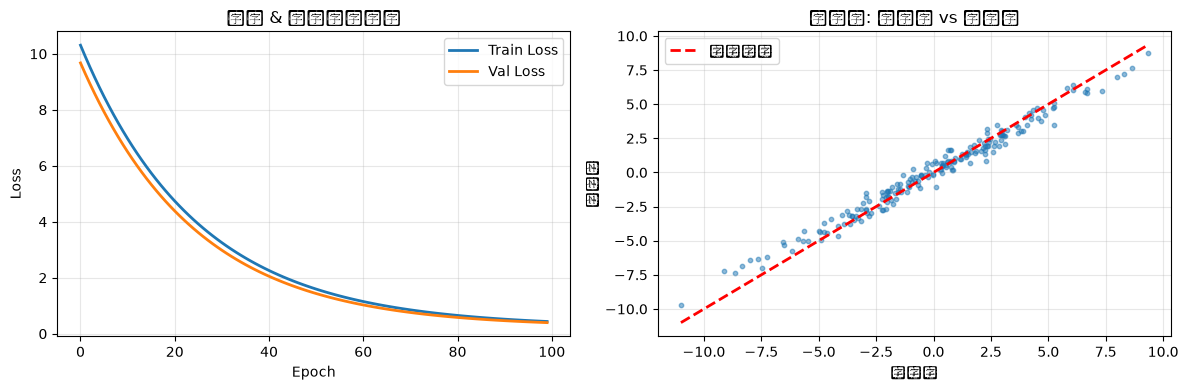

💡 左图：损失应持续下降；右图：点越贴近红线说明预测越准


In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 损失曲线
axes[0].plot(train_losses, label='Train Loss', linewidth=2)
axes[0].plot(val_losses, label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('训练 & 验证损失曲线')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 预测 vs 真实值
model.eval()
with torch.no_grad():
    y_val_pred = model(X_val)

axes[1].scatter(y_val.numpy(), y_val_pred.numpy(), alpha=0.5, s=10)
axes[1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()],
             'r--', linewidth=2, label='完美预测')
axes[1].set_xlabel('真实值')
axes[1].set_ylabel('预测值')
axes[1].set_title('验证集: 预测值 vs 真实值')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("💡 左图：损失应持续下降；右图：点越贴近红线说明预测越准")

### 4.5 训练循环的关键要素总结

```
典型的 PyTorch 训练循环：

for epoch in range(num_epochs):
    for batch in dataloader:          # 遍历数据
        optimizer.zero_grad()         # ① 清零梯度
        outputs = model(inputs)       # ② 前向传播
        loss = criterion(outputs, labels)  # ③ 计算损失
        loss.backward()               # ④ 反向传播（计算梯度）
        optimizer.step()              # ⑤ 更新参数
```

**关键注意事项**：
- `model.train()` vs `model.eval()`：影响 Dropout 和 BatchNorm 行为
- `torch.no_grad()`：验证/测试时必须使用，节省显存并加速
- `optimizer.zero_grad()`：每次迭代前必须清零，否则梯度会累积
- `loss.backward()`：PyTorch 自动计算所有 `requires_grad=True` 的参数的梯度

### 4.6 学习率调度器 (LR Scheduler)

学习率调度是训练大模型的关键技巧，在 Transformer 训练中尤为重要。

**💡 Transformer 训练标配**：Warmup + Cosine Annealing

C:\Users\WenhaoZou\AppData\Local\Temp\ipykernel_3704\2959426213.py:19: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()
C:\Users\WenhaoZou\AppData\Local\Temp\ipykernel_3704\2959426213.py:27: UserWarning: Glyph 38454 (\N{CJK UNIFIED IDEOGRAPH-9636}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\WenhaoZou\AppData\Local\Temp\ipykernel_3704\2959426213.py:27: UserWarning: Glyph 26799 (\N{CJK UNIFIED IDEOGRAPH-68AF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\WenhaoZou\AppData\Local\Temp\ipykernel_3704\2959426213.py:27: UserWarning: Glyph 34928 (\N{CJK UNIFIED IDEOGRAPH-8870}) missing from font(s) De

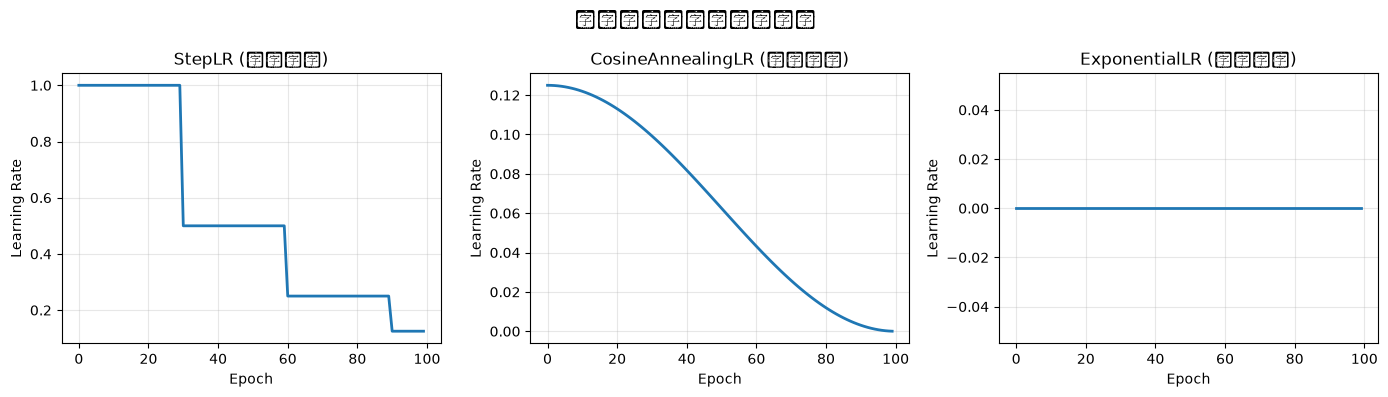

💡 CosineAnnealingLR 是 Transformer 训练中最常用的调度策略


In [26]:
model = SimpleNN(input_dim=10, hidden_dim=20, output_dim=1)
optimizer = optim.SGD(model.parameters(), lr=1.0)

# 各种调度器
schedulers = {
    "StepLR (阶梯衰减)": optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5),
    "CosineAnnealingLR (余弦退火)": optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100),
    "ExponentialLR (指数衰减)": optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95),
}

# 模拟 100 个 epoch 的学习率变化
epochs = list(range(100))
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, scheduler) in zip(axes, schedulers.items()):
    lrs = []
    for epoch in epochs:
        lrs.append(optimizer.param_groups[0]['lr'])
        scheduler.step()
    ax.plot(epochs, lrs, linewidth=2)
    ax.set_title(name)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Learning Rate')
    ax.grid(True, alpha=0.3)

plt.suptitle('不同学习率调度策略对比', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("💡 CosineAnnealingLR 是 Transformer 训练中最常用的调度策略")

---

## 第五部分：知识总结与面试要点

### 今日核心知识点回顾

| 知识点 | 关键内容 | 面试常见问法 |
|--------|---------|-------------|
| **Python 基础** | 列表推导式、生成器、装饰器、上下文管理器 | "用生成器处理大文件的优势是什么？" |
| **NumPy** | 广播机制、矩阵运算、线性代数 | "广播机制的规则是什么？" |
| **PyTorch Tensor** | 创建、索引、变形、设备转移、数据类型 | "Tensor 和 ndarray 的区别？" |
| **Autograd** | 计算图、链式法则、梯度计算 | "`loss.backward()` 内部做了什么？" |
| **训练循环** | 前向传播、损失计算、反向传播、参数更新 | "手写一个完整的训练循环" |
| **学习率调度** | Warmup、Cosine、Step 衰减 | "Transformer 为什么需要 Warmup？" |

### 拓展思考题

1. **为什么 `optimizer.zero_grad()` 必须在 `loss.backward()` 之前调用？**
   - 因为 `backward()` 会累积梯度，如果不清零，梯度会越来越大。

2. **`model.eval()` 和 `torch.no_grad()` 有什么区别？**
   - `model.eval()` 改变模型行为（关闭 Dropout、固定 BatchNorm）
   - `torch.no_grad()` 关闭自动求导（节省显存，加速推理）

3. **广播机制在 Attention 计算中如何体现？**
   - 在计算 Q @ K^T 时，`(batch, heads, seq, d_k) @ (batch, heads, d_k, seq)` 利用了广播。

---
*明天预告：Day 2 —— 手撕神经网络训练，从零实现前馈神经网络与反向传播。*